<a href="https://colab.research.google.com/github/inw1ze/SQL-study-project/blob/main/%D0%A0%D0%B0%D0%B7%D0%B1%D0%BE%D1%80_%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B3%D0%BE_dataviz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://gist.githubusercontent.com/andron23/f965229448f815dffa9a61bd701c0538/raw/5e309e67ae6515fd09516cbe18a4b21189052617/coderun.csv

--2026-03-11 17:13:00--  https://gist.githubusercontent.com/andron23/f965229448f815dffa9a61bd701c0538/raw/5e309e67ae6515fd09516cbe18a4b21189052617/coderun.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 779437 (761K) [text/plain]
Saving to: ‘coderun.csv’

coderun.csv         100%[===================>] 761.17K  --.-KB/s    in 0.05s   

2026-03-11 17:13:00 (15.2 MB/s) - ‘coderun.csv’ saved [779437/779437]



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('coderun.csv')

df['ymd'] = pd.to_datetime(df['created_at']).dt.date

df['ym'] = pd.to_datetime(df['created_at']).dt.strftime('%Y-%m')

In [ ]:
print(df)

          id               created_at  problem_id  user_id  language_id  \
0          1  2021-04-07 06:06:20.000          13       10            3   
1          2  2021-03-31 07:10:06.000          15       13            3   
2          3  2021-04-04 14:55:26.000           1        6            3   
3          4  2021-03-29 21:24:51.000          26        4            3   
4          5  2021-03-30 11:29:12.000          21       18            3   
...      ...                      ...         ...      ...          ...   
19995  19996  2022-02-02 19:55:47.705         133     1050            2   
19996  19997  2022-02-02 19:56:01.579         133     1050            2   
19997  19998  2022-02-02 19:56:21.652         133     1050            2   
19998  19999  2022-02-02 19:57:06.437         116      502            2   
19999  20000  2022-02-02 19:57:16.320         133     1050            2   

              ymd       ym  
0      2021-04-07  2021-04  
1      2021-03-31  2021-03  
2      2021-

# 1

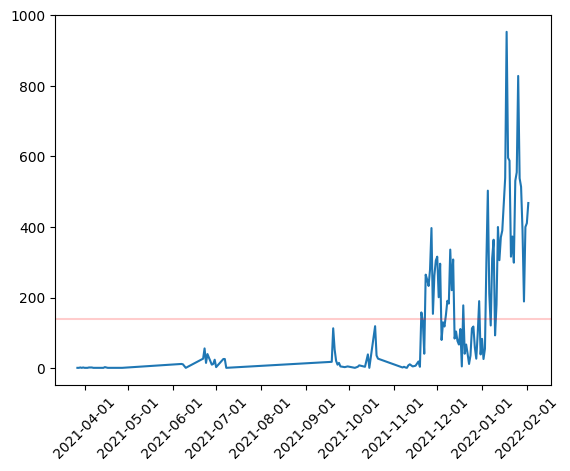

In [ ]:
_df = df.groupby('ymd')['ymd'].agg({'count'}).reset_index()

plt.plot(_df['ymd'], _df['count']);

plt.xticks(plt.xticks()[0], rotation=45);

plt.axhline(_df['count'].mean(), alpha=0.2, color='red');

# 2

In [ ]:
_df = df.groupby(['ymd', 'language_id'])['problem_id'].agg({'count'}).reset_index()

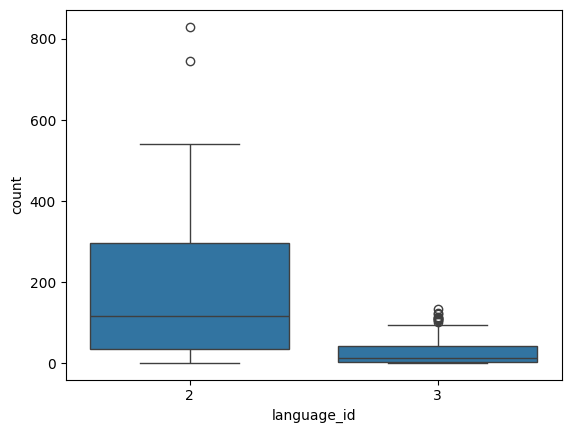

In [ ]:
sns.boxplot(data=_df, y="count", x="language_id");

# 3

In [ ]:
_df = df[df['ym'] >= '2021-12'].groupby(['ym', 'ymd', 'language_id'])['problem_id'].agg({'count'}).reset_index()

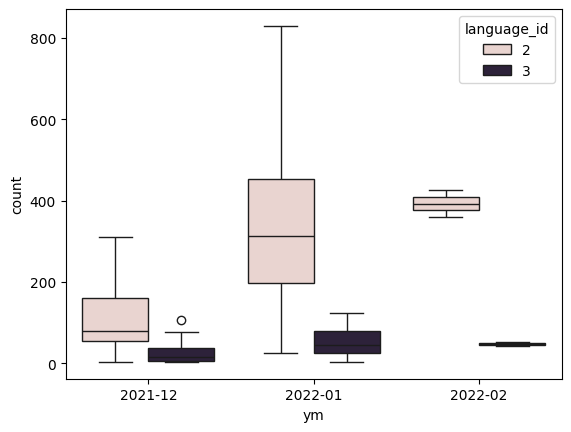

In [ ]:
sns.boxplot(data=_df, y="count", x="ym", hue='language_id');

# 4

In [ ]:
_df = df.groupby(['user_id'])['problem_id'].agg({'nunique'}).reset_index()

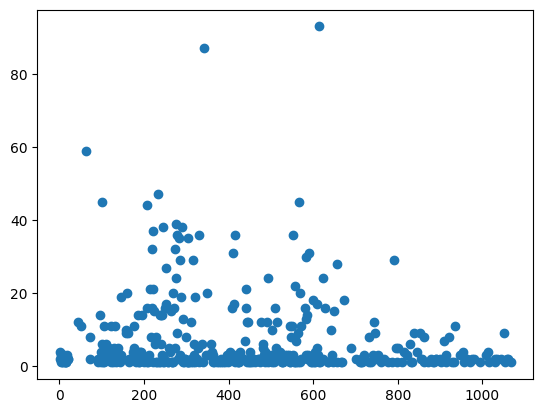

In [ ]:
plt.scatter(_df['user_id'], _df['nunique'])

# 5

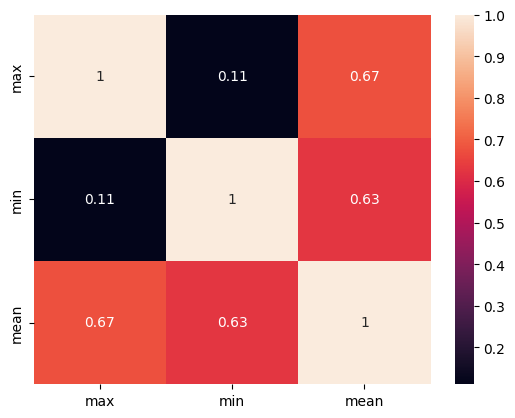

In [ ]:
_df = df.groupby(['user_id', 'problem_id'])['language_id'].agg({'count'}).reset_index()[['user_id', 'count']].groupby('user_id')['count'].agg({'max', 'min', 'mean'}).reset_index()

sns.heatmap(_df[['max', 'min', 'mean']].corr(), annot=True, min = -1);

# 6

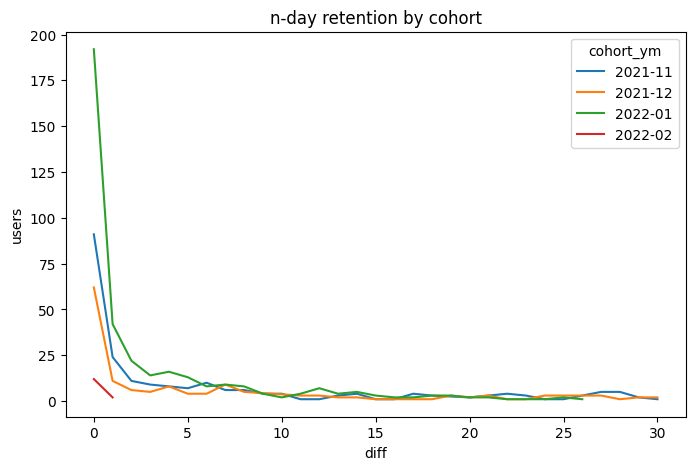

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['created_at'] = pd.to_datetime(df['created_at'])
df['ymd'] = df['created_at'].dt.normalize()
df['first_attempt'] = df.groupby('user_id')['ymd'].transform('min')
df['cohort_ym'] = df['first_attempt'].dt.strftime('%Y-%m')
df['diff'] = (df['ymd'] - df['first_attempt']).dt.days
df = df[df['cohort_ym'] >= '2021-11']
df = df[(df['diff'] >= 0) & (df['diff'] <= 30)]

ret = (
    df.groupby(['cohort_ym','diff'])['user_id']
    .nunique()
    .reset_index(name='users')
)


plt.figure(figsize=(8,5))
sns.lineplot(data=ret, x='diff', y='users', hue='cohort_ym')

plt.xlabel('diff')
plt.ylabel('users')
plt.title('n-day retention by cohort')

plt.show()

# 7

In [ ]:
_df = df.groupby(['ymd', 'language_id'])['user_id'].agg({'nunique'}).reset_index()

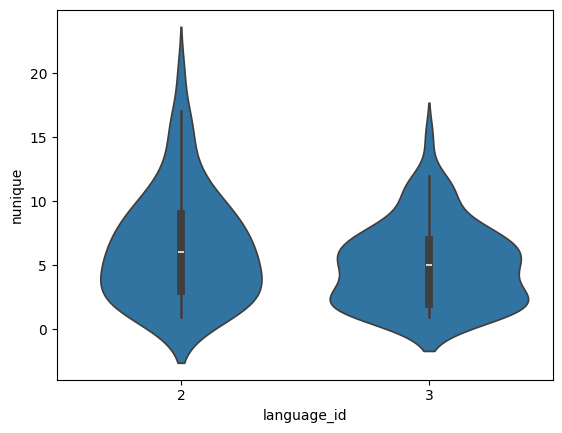

In [ ]:
sns.violinplot(x=_df['language_id'], y=_df['nunique']);